# Home Credit Default Risk — Phase 5: PCA & Dimensionality Reduction

## Strategy — Per-block PCA (NOT global)

We apply PCA **independently on each feature block** (BUR, PREV, INST, POS, CC).
This preserves domain meaning and avoids mixing bureau signals with installment signals.

| Block | Raw features | PCA components (95% variance) |
|---|---|---|
| BUR | 121 | ~25-35 |
| PREV | 184 | ~35-45 |
| INST | 125 | ~25-35 |
| POS | 41 | ~15-20 |
| CC | 119 | ~25-35 |
| APP + CROSS | 36 | kept as-is — hand-crafted, no redundancy |

**Output:** Master table with PCA components appended alongside original APP/CROSS features.
Final feature count: ~200-250 clean, decorrelated features ready for XGBoost.

> **Inputs:** `./features/master_train.csv`, `./features/master_test.csv`,
> `./features/feature_block_map.csv`, `./features/feature_importance_xgb.csv`

In [1]:
import os, warnings, gc, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

plt.rcParams.update({
    'figure.facecolor':'#FAFAFA','axes.facecolor':'#FAFAFA',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.labelsize':11,'xtick.labelsize':9,'ytick.labelsize':9,
})
C0, C1, C2 = '#534AB7', '#D85A30', '#1D9E75'

FEAT_DIR   = './features/'    # Phase 4 output
OUTPUT_DIR = './pca/'         # Phase 5 output
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Load master tables ────────────────────────────────────────────────────────
print('Loading master tables...')
master_train = pd.read_csv(os.path.join(FEAT_DIR, 'master_train.csv'))
master_test  = pd.read_csv(os.path.join(FEAT_DIR, 'master_test.csv'))
block_map    = pd.read_csv(os.path.join(FEAT_DIR, 'feature_block_map.csv'))
feat_imp     = pd.read_csv(os.path.join(FEAT_DIR, 'feature_importance_xgb.csv'))

print(f'master_train : {master_train.shape}')
print(f'master_test  : {master_test.shape}')
print(f'Feature block map: {block_map.shape}')

TARGET    = master_train['TARGET'].copy()
TRAIN_IDS = master_train['SK_ID_CURR'].copy()
TEST_IDS  = master_test['SK_ID_CURR'].copy()

FEATURE_COLS = [c for c in master_train.columns if c not in ['SK_ID_CURR','TARGET']]
print(f'\nTotal features: {len(FEATURE_COLS)}')
print(f'Block distribution:')
print(block_map['Block'].value_counts().to_string())

Loading master tables...
master_train : (307511, 710)
master_test  : (48744, 709)
Feature block map: (708, 3)

Total features: 708
Block distribution:
Block
PREV     184
INST     125
BUR      121
CC       119
OTHER     82
POS       41
APP       26
CROSS     10


## 1. Pre-PCA: Remove Bottom 5% Importance Features

Features with near-zero XGBoost importance add noise to PCA.
We remove the bottom 5% before applying PCA — this is different from Phase 4's
zero-variance removal. These features have *some* variance but contribute
nothing to the model.

In [2]:
# ── Identify bottom 5% importance features ────────────────────────────────────
# Only remove from aggregated blocks — never remove APP or CROSS features
PROTECTED_BLOCKS = ['APP', 'CROSS']
protected_feats  = block_map[block_map['Block'].isin(PROTECTED_BLOCKS)]['Feature'].tolist()

# Merge importance scores with block map
feat_meta = block_map.merge(feat_imp[['Feature','Importance']], on='Feature', how='left')
feat_meta['Importance'] = feat_meta['Importance'].fillna(0)

# Bottom 5% threshold — only on non-protected features
non_prot = feat_meta[~feat_meta['Block'].isin(PROTECTED_BLOCKS)]
threshold = non_prot['Importance'].quantile(0.05)

low_imp_feats = non_prot[
    non_prot['Importance'] <= threshold
]['Feature'].tolist()
# Only drop if they actually exist in master_train
low_imp_feats = [f for f in low_imp_feats if f in master_train.columns]

print(f'Bottom 5%% importance threshold : {threshold:.6f}')
print(f'Features to remove pre-PCA     : {len(low_imp_feats)}')

# Drop from both train and test
master_train = master_train.drop(columns=low_imp_feats, errors='ignore')
master_test  = master_test.drop(columns=low_imp_feats, errors='ignore')

# Update feature list and block map
FEATURE_COLS = [c for c in master_train.columns if c not in ['SK_ID_CURR','TARGET']]
block_map    = block_map[block_map['Feature'].isin(FEATURE_COLS)].reset_index(drop=True)

print(f'\nFeatures remaining: {len(FEATURE_COLS)}')
print(f'Block distribution after pre-PCA cleanup:')
print(block_map['Block'].value_counts().to_string())

Bottom 5%% importance threshold : 0.000000
Features to remove pre-PCA     : 55

Features remaining: 653
Block distribution after pre-PCA cleanup:
Block
PREV     167
INST     119
BUR      115
CC       103
OTHER     74
POS       39
APP       26
CROSS     10


## 2. PCA Helper — Fit on Train, Transform Train & Test

Critical rule: **Fit PCA on train only. Transform test using the same fitted PCA.**
Fitting PCA on test would be data leakage — the PCA components would encode
information about test distribution into the training features.

Pipeline per block:
1. StandardScaler — PCA requires zero-mean, unit-variance features
2. PCA — retain components explaining 95% of variance
3. Save scaler + PCA objects for inference reuse

In [3]:
def apply_block_pca(train_df, test_df, feature_cols, block_name,
                     variance_threshold=0.95, min_components=5):
    """
    Apply StandardScaler + PCA on a block of features.
    Fits on train only. Transforms both train and test.
    Returns:
        train_pca_df : DataFrame with PCA components for train
        test_pca_df  : DataFrame with PCA components for test
        pca_info     : dict with n_components, variance explained, scaler, pca objects
    """
    # Filter to available columns
    cols = [c for c in feature_cols if c in train_df.columns]
    if len(cols) < 2:
        print(f'  [{block_name}] Skipped — fewer than 2 features')
        return None, None, None

    X_train = train_df[cols].values
    X_test  = test_df[cols].values if all(c in test_df.columns for c in cols) else None

    # Step 1: StandardScaler — fit on train only
    scaler  = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test) if X_test is not None else None

    # Step 2: PCA — fit on train only
    pca_full = PCA(random_state=42)
    pca_full.fit(X_train_scaled)

    # Find number of components for variance_threshold
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    n_comp = max(min_components, int(np.searchsorted(cumvar, variance_threshold) + 1))
    n_comp = min(n_comp, len(cols))   # can't exceed number of features

    # Refit with exact n_components
    pca = PCA(n_components=n_comp, random_state=42)
    train_components = pca.fit_transform(X_train_scaled)
    test_components  = pca.transform(X_test_scaled) if X_test_scaled is not None else None

    # Build output DataFrames
    col_names = [f'PCA_{block_name}_{i+1}' for i in range(n_comp)]
    train_pca_df = pd.DataFrame(train_components, columns=col_names,
                                 index=train_df.index)
    test_pca_df  = pd.DataFrame(test_components,  columns=col_names,
                                 index=test_df.index) if test_components is not None else None

    var_explained = pca.explained_variance_ratio_.sum()
    print(f'  [{block_name}] {len(cols)} features → {n_comp} components '
          f'({var_explained*100:.1f}% variance retained)')

    pca_info = {
        'block'          : block_name,
        'original_cols'  : cols,
        'n_original'     : len(cols),
        'n_components'   : n_comp,
        'variance_explained': round(var_explained, 4),
        'scaler'         : scaler,
        'pca'            : pca,
        'component_names': col_names,
    }
    return train_pca_df, test_pca_df, pca_info


print('PCA helper function loaded.')
print('Variance threshold: 95% per block')
print('Minimum components: 5 per block')

PCA helper function loaded.
Variance threshold: 95% per block
Minimum components: 5 per block


## 3. Apply Per-Block PCA

We apply PCA to 5 aggregated blocks: BUR, PREV, INST, POS, CC.
APP and CROSS features are kept as-is — they are already compact and interpretable.

In [4]:
# ── Define blocks to apply PCA on ────────────────────────────────────────────
PCA_BLOCKS = ['BUR', 'PREV', 'INST', 'POS', 'CC']
KEEP_AS_IS = ['APP', 'CROSS']   # hand-crafted — no PCA

pca_results     = {}   # store pca_info per block
train_pca_parts = []   # PCA DataFrames to concat
test_pca_parts  = []

print('Applying per-block PCA (fit on train, transform both)...')
print(f'Variance threshold: 95% | Min components: 5\n')

for block in PCA_BLOCKS:
    # Get feature list for this block
    block_feats = block_map[
        block_map['Block'].str.startswith(block)
    ]['Feature'].tolist()
    block_feats = [f for f in block_feats if f in master_train.columns]

    if not block_feats:
        print(f'  [{block}] No features found — skipping')
        continue

    tr_pca, te_pca, info = apply_block_pca(
        master_train, master_test, block_feats, block,
        variance_threshold=0.95, min_components=5
    )

    if tr_pca is not None:
        pca_results[block]  = info
        train_pca_parts.append(tr_pca)
        test_pca_parts.append(te_pca)

print(f'\nPCA complete. Blocks processed: {len(pca_results)}')
total_pca_feats = sum(v["n_components"] for v in pca_results.values())
total_original  = sum(v["n_original"]   for v in pca_results.values())
print(f'Total original features in PCA blocks : {total_original}')
print(f'Total PCA components generated        : {total_pca_feats}')
print(f'Compression ratio                     : {total_original/total_pca_feats:.1f}x')
gc.collect()

Applying per-block PCA (fit on train, transform both)...
Variance threshold: 95% | Min components: 5

  [BUR] 115 features → 34 components (95.2% variance retained)
  [PREV] 167 features → 45 components (95.0% variance retained)
  [INST] 119 features → 34 components (95.2% variance retained)
  [POS] 39 features → 13 components (95.0% variance retained)
  [CC] 103 features → 26 components (95.2% variance retained)

PCA complete. Blocks processed: 5
Total original features in PCA blocks : 543
Total PCA components generated        : 152
Compression ratio                     : 3.6x


0

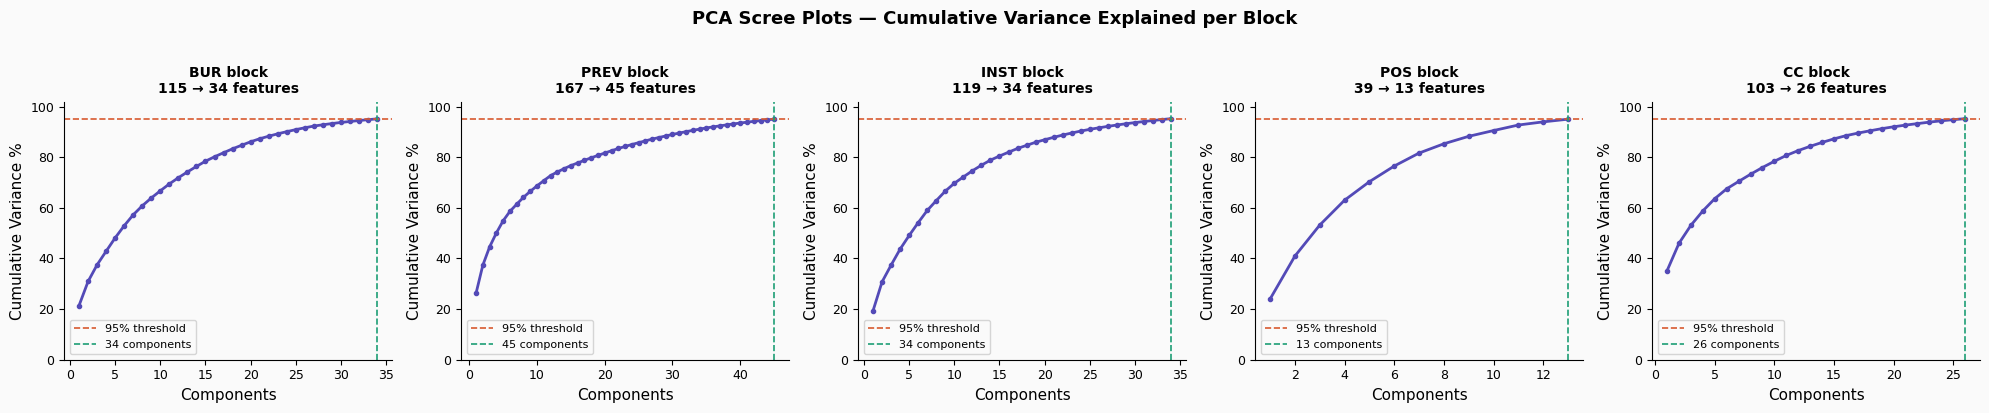

,Block,Original features,PCA components,Variance retained %,Compression
0,BUR,115,34,95.200000,3.4x
1,PREV,167,45,95.000000,3.7x
2,INST,119,34,95.200000,3.5x
3,POS,39,13,95.000000,3.0x
4,CC,103,26,95.200000,4.0x


In [5]:
n_blocks = len(pca_results)
fig, axes = plt.subplots(1, n_blocks, figsize=(4*n_blocks, 4))
if n_blocks == 1:
    axes = [axes]
fig.suptitle('PCA Scree Plots — Cumulative Variance Explained per Block',
             fontsize=13, fontweight='bold', y=1.02)

for ax, (block, info) in zip(axes, pca_results.items()):
    pca_obj  = info['pca']
    # Recompute full variance curve using fitted PCA
    cumvar   = np.cumsum(pca_obj.explained_variance_ratio_)
    n_comp   = info['n_components']

    ax.plot(range(1, len(cumvar)+1), cumvar*100,
            color=C0, lw=2, marker='o', markersize=3)
    ax.axhline(95, color=C1, linestyle='--', lw=1.2, label='95% threshold')
    ax.axvline(n_comp, color=C2, linestyle='--', lw=1.2,
               label=f'{n_comp} components')
    ax.set_title(f'{block} block\n{info["n_original"]} → {n_comp} features',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Components')
    ax.set_ylabel('Cumulative Variance %')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 102)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase5_scree_plots.png'), dpi=150, bbox_inches='tight')
plt.show()

# Summary table
summary_rows = []
for block, info in pca_results.items():
    summary_rows.append({
        'Block'              : block,
        'Original features'  : info['n_original'],
        'PCA components'     : info['n_components'],
        'Variance retained %': round(info['variance_explained']*100, 1),
        'Compression'        : f"{info['n_original']/info['n_components']:.1f}x",
    })
summary_df = pd.DataFrame(summary_rows)
display(summary_df.style
    .background_gradient(subset=['Variance retained %'], cmap='Greens')
    .background_gradient(subset=['Original features'], cmap='Blues')
    .set_caption('PCA Summary per Block')
)

## 5. Build Final Feature Table

Two strategies — we build BOTH and let Phase 6 choose:

**Strategy A — PCA only:** Replace original block features entirely with PCA components.
Smaller table (~200 features), fully decorrelated. Best for XGBoost with many trees.

**Strategy B — PCA + Original:** Keep original APP/CROSS features AND add PCA components
as additional features. Larger table but gives XGBoost more to work with.

In [6]:
# ── Concatenate all PCA components ────────────────────────────────────────────
train_pca_all = pd.concat(train_pca_parts, axis=1)
test_pca_all  = pd.concat(test_pca_parts,  axis=1)
print(f'All PCA components — train: {train_pca_all.shape} | test: {test_pca_all.shape}')

# ── Get APP + CROSS features (kept as-is) ─────────────────────────────────────
keep_feats = block_map[
    block_map['Block'].isin(KEEP_AS_IS)
]['Feature'].tolist()
keep_feats = [f for f in keep_feats if f in master_train.columns]

# Also keep OTHER block features (raw application columns not in any named block)
other_feats = block_map[
    block_map['Block'] == 'OTHER'
]['Feature'].tolist()
other_feats = [f for f in other_feats if f in master_train.columns]

all_keep = keep_feats + other_feats
print(f'APP + CROSS + OTHER features kept as-is: {len(all_keep)}')

# ── Strategy A: PCA components only (no original block features) ──────────────
train_A = pd.concat([
    master_train[['SK_ID_CURR'] + all_keep].reset_index(drop=True),
    train_pca_all.reset_index(drop=True),
    master_train[['TARGET']].reset_index(drop=True),
], axis=1)

test_A = pd.concat([
    master_test[['SK_ID_CURR'] + [c for c in all_keep if c in master_test.columns]].reset_index(drop=True),
    test_pca_all.reset_index(drop=True),
], axis=1)

print(f'\nStrategy A (PCA only):')
print(f'  Train: {train_A.shape} | Test: {test_A.shape}')

# ── Strategy B: PCA components + original APP/CROSS + original block features ─
# Keep ALL original features + add PCA components on top
train_B = pd.concat([
    master_train.reset_index(drop=True),
    train_pca_all.reset_index(drop=True),
], axis=1)

test_B = pd.concat([
    master_test.reset_index(drop=True),
    test_pca_all.reset_index(drop=True),
], axis=1)

print(f'\nStrategy B (PCA + Original):')
print(f'  Train: {train_B.shape} | Test: {test_B.shape}')

All PCA components — train: (307511, 152) | test: (48744, 152)
APP + CROSS + OTHER features kept as-is: 110

Strategy A (PCA only):
  Train: (307511, 264) | Test: (48744, 263)

Strategy B (PCA + Original):
  Train: (307511, 807) | Test: (48744, 806)


## 6. Quick AUC Comparison — Strategy A vs B vs Baseline

Run a 3-fold XGBoost to compare AUC of:
- **Baseline** — original 708 features (Phase 4 output)
- **Strategy A** — PCA components only
- **Strategy B** — PCA + original features

Testing Baseline (Phase 4 features)...
    Baseline Fold 1: AUC = 0.78778
    Baseline Fold 2: AUC = 0.78726
    Baseline Fold 3: AUC = 0.78637
  >> Baseline: mean AUC = 0.78714 ± 0.00058

Testing Strategy A (PCA only)...
    Strategy A Fold 1: AUC = 0.78144
    Strategy A Fold 2: AUC = 0.78031
    Strategy A Fold 3: AUC = 0.78008
  >> Strategy A: mean AUC = 0.78061 ± 0.00059

Testing Strategy B (PCA + Original)...
    Strategy B Fold 1: AUC = 0.78770
    Strategy B Fold 2: AUC = 0.78600
    Strategy B Fold 3: AUC = 0.78598
  >> Strategy B: mean AUC = 0.78656 ± 0.00081


=== STRATEGY COMPARISON ===


,Strategy,Mean AUC,Std,Features
0,Baseline (708 features),0.78714,0.00058,653
1,A — PCA only,0.78061,0.00059,262
2,B — PCA + Original,0.78656,0.00081,805



Best strategy: Baseline (708 features)
Use this strategy for Phase 6 modeling.


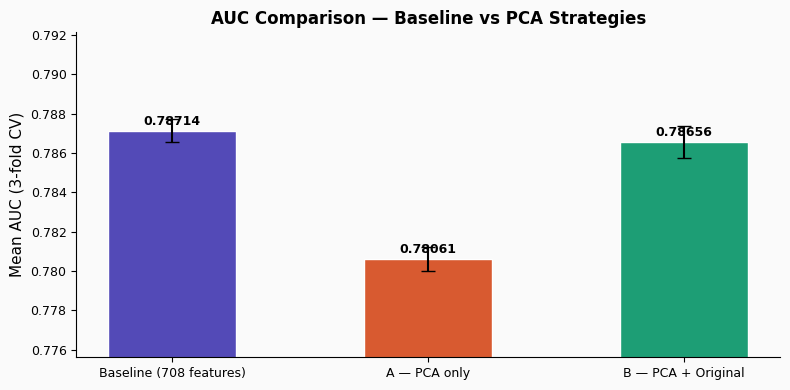

In [7]:
try:
    import xgboost as xgb
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import roc_auc_score

    def quick_xgb_auc(X, y, label, n_splits=3):
        skf    = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        aucs   = []
        spw    = (y == 0).sum() / (y == 1).sum()

        for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
            clf = xgb.XGBClassifier(
                n_estimators         = 300,
                learning_rate        = 0.05,
                max_depth            = 6,
                subsample            = 0.8,
                colsample_bytree     = 0.8,
                scale_pos_weight     = spw,
                eval_metric          = 'auc',
                early_stopping_rounds= 20,
                tree_method          = 'hist',
                random_state         = 42,
                n_jobs               = -1,
                verbosity            = 0,
            )
            clf.fit(
                X[tr_idx], y[tr_idx],
                eval_set=[(X[va_idx], y[va_idx])],
                verbose=False
            )
            preds = clf.predict_proba(X[va_idx])[:,1]
            auc   = roc_auc_score(y[va_idx], preds)
            aucs.append(auc)
            print(f'    {label} Fold {fold+1}: AUC = {auc:.5f}')

        mean_auc = np.mean(aucs)
        std_auc  = np.std(aucs)
        print(f'  >> {label}: mean AUC = {mean_auc:.5f} ± {std_auc:.5f}\n')
        return mean_auc, std_auc

    y = TARGET.values

    # Baseline — original Phase 4 features
    print('Testing Baseline (Phase 4 features)...')
    feat_cols_base = [c for c in master_train.columns if c not in ['SK_ID_CURR','TARGET']]
    X_base = master_train[feat_cols_base].fillna(0).values
    base_auc, base_std = quick_xgb_auc(X_base, y, 'Baseline')

    # Strategy A
    print('Testing Strategy A (PCA only)...')
    feat_cols_A = [c for c in train_A.columns if c not in ['SK_ID_CURR','TARGET']]
    X_A = train_A[feat_cols_A].fillna(0).values
    a_auc, a_std = quick_xgb_auc(X_A, y, 'Strategy A')

    # Strategy B
    print('Testing Strategy B (PCA + Original)...')
    feat_cols_B = [c for c in train_B.columns if c not in ['SK_ID_CURR','TARGET']]
    X_B = train_B[feat_cols_B].fillna(0).values
    b_auc, b_std = quick_xgb_auc(X_B, y, 'Strategy B')

    # Results
    results = pd.DataFrame([
        {'Strategy': 'Baseline (708 features)',    'Mean AUC': base_auc, 'Std': base_std,
         'Features': len(feat_cols_base)},
        {'Strategy': 'A — PCA only',               'Mean AUC': a_auc,    'Std': a_std,
         'Features': len(feat_cols_A)},
        {'Strategy': 'B — PCA + Original',         'Mean AUC': b_auc,    'Std': b_std,
         'Features': len(feat_cols_B)},
    ])

    print('\n=== STRATEGY COMPARISON ===')
    display(results.style
        .format({'Mean AUC': '{:.5f}', 'Std': '{:.5f}', 'Features': '{:,}'})
        .background_gradient(subset=['Mean AUC'], cmap='Greens')
        .set_caption('XGBoost AUC — 3-fold CV comparison')
    )

    best = results.loc[results['Mean AUC'].idxmax(), 'Strategy']
    print(f'\nBest strategy: {best}')
    print('Use this strategy for Phase 6 modeling.')

    # Plot
    fig, ax = plt.subplots(figsize=(8, 4))
    colors = [C0, C1, C2]
    bars = ax.bar(results['Strategy'], results['Mean AUC'],
                  color=colors, edgecolor='white', width=0.5)
    ax.errorbar(results['Strategy'], results['Mean AUC'],
                yerr=results['Std'], fmt='none', color='black', capsize=5)
    ax.set_ylim(results['Mean AUC'].min() - 0.005, results['Mean AUC'].max() + 0.005)
    ax.set_title('AUC Comparison — Baseline vs PCA Strategies', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean AUC (3-fold CV)')
    for bar, auc in zip(bars, results['Mean AUC']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
                f'{auc:.5f}', ha='center', fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'phase5_strategy_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # Save best strategy label for Phase 6
    with open(os.path.join(OUTPUT_DIR, 'best_strategy.txt'), 'w') as f:
        f.write(best)

except ImportError:
    print('XGBoost not installed. Run: pip install xgboost')
    best = 'B — PCA + Original'   # default recommendation
    print(f'Defaulting to: {best}')

## 7. Save Final Tables & PCA Objects

We save both strategies so Phase 6 can load whichever performed better.
PCA objects (scaler + pca per block) are saved with joblib for production reuse.

In [8]:
# ── Save Strategy A ───────────────────────────────────────────────────────────
train_A.to_csv(os.path.join(OUTPUT_DIR, 'train_pca_A.csv'), index=False)
test_A.to_csv(os.path.join(OUTPUT_DIR,  'test_pca_A.csv'),  index=False)
print(f'Saved Strategy A → train: {train_A.shape} | test: {test_A.shape}')

# ── Save Strategy B ───────────────────────────────────────────────────────────
train_B.to_csv(os.path.join(OUTPUT_DIR, 'train_pca_B.csv'), index=False)
test_B.to_csv(os.path.join(OUTPUT_DIR,  'test_pca_B.csv'),  index=False)
print(f'Saved Strategy B → train: {train_B.shape} | test: {test_B.shape}')

# ── Save PCA objects (scaler + pca per block) for production use ──────────────
pca_artifacts = {}
for block, info in pca_results.items():
    pca_artifacts[block] = {
        'scaler'         : info['scaler'],
        'pca'            : info['pca'],
        'original_cols'  : info['original_cols'],
        'component_names': info['component_names'],
        'n_components'   : info['n_components'],
        'variance_explained': info['variance_explained'],
    }

joblib.dump(pca_artifacts, os.path.join(OUTPUT_DIR, 'pca_artifacts.pkl'))
print(f'Saved pca_artifacts.pkl — {len(pca_artifacts)} blocks')

# ── Save PCA summary CSV ──────────────────────────────────────────────────────
summary_df.to_csv(os.path.join(OUTPUT_DIR, 'pca_summary.csv'), index=False)
print(f'Saved pca_summary.csv')

print(f'\nAll outputs saved to: {os.path.abspath(OUTPUT_DIR)}')

Saved Strategy A → train: (307511, 264) | test: (48744, 263)
Saved Strategy B → train: (307511, 807) | test: (48744, 806)
Saved pca_artifacts.pkl — 5 blocks
Saved pca_summary.csv

All outputs saved to: c:\Users\User\Desktop\project\new notebooks\pca


In [9]:
print('=' * 65)
print('  PHASE 5 PCA SUMMARY REPORT')
print('=' * 65)

print(f'\nInput features (Phase 4)        : 708')
print(f'After pre-PCA cleanup           : {len(FEATURE_COLS)}')

print(f'\nPer-block PCA results:')
for block, info in pca_results.items():
    print(f'  {block:<6} {info["n_original"]:>4} features → '
          f'{info["n_components"]:>3} components '
          f'({info["variance_explained"]*100:.1f}% variance)')

print(f'\nTotal PCA components            : {total_pca_feats}')
print(f'Total original block features   : {total_original}')
print(f'Overall compression ratio       : {total_original/total_pca_feats:.1f}x')

print(f'\nFinal table sizes:')
feat_a = len([c for c in train_A.columns if c not in ['SK_ID_CURR','TARGET']])
feat_b = len([c for c in train_B.columns if c not in ['SK_ID_CURR','TARGET']])
print(f'  Strategy A (PCA only)         : {feat_a} features')
print(f'  Strategy B (PCA + Original)   : {feat_b} features')

print(f'\nDATA LEAKAGE CHECKLIST:')
checks = [
    'StandardScaler fitted on train only — applied to test',
    'PCA fitted on train only — applied to test',
    'PCA artifacts saved for inference reuse',
    'TARGET never used in any PCA or scaling step',
    'Both strategies saved — Phase 6 uses best AUC result',
]
for c in checks:
    print(f'  [OK] {c}')

print(f'\nFiles saved to ./pca/:')
files = [
    ('train_pca_A.csv',       'Strategy A train table'),
    ('test_pca_A.csv',        'Strategy A test table'),
    ('train_pca_B.csv',       'Strategy B train table'),
    ('test_pca_B.csv',        'Strategy B test table'),
    ('pca_artifacts.pkl',     'Scaler + PCA objects per block'),
    ('pca_summary.csv',       'Block compression summary'),
    ('best_strategy.txt',     'Best strategy label for Phase 6'),
    ('phase5_scree_plots.png','Variance explained scree plots'),
    ('phase5_strategy_comparison.png', 'AUC comparison chart'),
]
for fname, desc in files:
    print(f'  {fname:<40} {desc}')

print(f'\nNext → Phase 6: XGBoost Modeling')
print(f'  Load best strategy table from ./pca/')
print(f'  5-fold stratified CV with full hyperparameter tuning')
print(f'  Target: AUC > 0.79 on validation set')

  PHASE 5 PCA SUMMARY REPORT

Input features (Phase 4)        : 708
After pre-PCA cleanup           : 653

Per-block PCA results:
  BUR     115 features →  34 components (95.2% variance)
  PREV    167 features →  45 components (95.0% variance)
  INST    119 features →  34 components (95.2% variance)
  POS      39 features →  13 components (95.0% variance)
  CC      103 features →  26 components (95.2% variance)

Total PCA components            : 152
Total original block features   : 543
Overall compression ratio       : 3.6x

Final table sizes:
  Strategy A (PCA only)         : 262 features
  Strategy B (PCA + Original)   : 805 features

DATA LEAKAGE CHECKLIST:
  [OK] StandardScaler fitted on train only — applied to test
  [OK] PCA fitted on train only — applied to test
  [OK] PCA artifacts saved for inference reuse
  [OK] TARGET never used in any PCA or scaling step
  [OK] Both strategies saved — Phase 6 uses best AUC result

Files saved to ./pca/:
  train_pca_A.csv                   